In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# parameters
reg = "megye"
ind = 3

In [17]:
# load data
tr_df = pd.read_csv("../data/oc_2022_november/transactions_indreg_nace3d_megye.csv", sep=";")
mne_df = pd.read_csv("../data/oc_2022_november/mne_share_nace3d_megye.csv", sep=";")

In [18]:
# generate industry-region ids
tr_df["ir_id1"] = tr_df["megye_kod1"].astype(str) + "-" + tr_df["nace3d1"].astype(str)
tr_df["ir_id2"] = tr_df["megye_kod2"].astype(str) + "-" + tr_df["nace3d2"].astype(str)
mne_df["ir_id"] = mne_df["megye_kod"].astype(str) + "-" + mne_df["nace3d"].astype(str)

In [19]:
# combine data
tr_df = pd.merge(
    tr_df,
    mne_df[["ir_id", "mne_dom_25", "mne_dom_50", "mne_dom_75"]],
    left_on=["ir_id1"],
    right_on=["ir_id"],
    how="left"
)
tr_df = pd.merge(
    tr_df,
    mne_df[["ir_id", "mne_dom_25", "mne_dom_50", "mne_dom_75"]],
    left_on="ir_id2",
    right_on=["ir_id"],
    how="left",
    suffixes=["_1", "_2"]
)

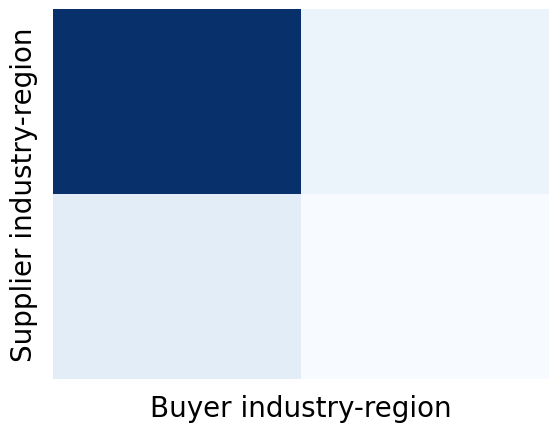

In [47]:
def ties_across_groups(df, index_col, column_col, normalized, heatmap, fontsize, ax=None):
    # dataframe prep
    df["tie"] = 1
    df = df.drop_duplicates(subset=["ir_id1", "ir_id2"])

    # pivot table construction
    table = pd.pivot_table(
        df,
        values="tie",
        index=index_col,
        columns=column_col,
        aggfunc=np.sum
    )
    
    if normalized == True:
        table = table / df["tie"].sum()
    else:
        table = table
    
    # visualization option
    if heatmap==False:
        return table
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(table, cbar=False, cmap="Blues", ax=ax)
        ax.set_xlabel("Buyer industry-region", size=fontsize)
        ax.set_ylabel("Supplier industry-region", size=fontsize)
        ax.set_xticklabels("")
        ax.set_yticklabels("")
        ax.tick_params(left = False, bottom = False)
        
        
ties_across_groups(tr_df, index_col="mne_dom_50_1", column_col="mne_dom_50_2", normalized=True, heatmap=True, fontsize=20)